Imports and paths

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PRICE_PATH = RAW_DATA_DIR / "price.csv"
NEWS_PATH = RAW_DATA_DIR / "news.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Price data found: {PRICE_PATH.exists()}")
print(f"News data found: {NEWS_PATH.exists()}")

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/camilo/stock-news-forecasting
Price data found: True
News data found: True


Load data

In [2]:
prices_raw = pd.read_csv(
    PRICE_PATH,
    parse_dates=["date"],
)

news_raw = pd.read_csv(
    NEWS_PATH,
    parse_dates=["datetime"],
)

print(f"Price dataset: {prices_raw.shape[0]:,} rows × {prices_raw.shape[1]} columns")
print(f"News dataset:  {news_raw.shape[0]:,} rows × {news_raw.shape[1]} columns")

display(prices_raw.head())
display(news_raw.head())

Price dataset: 1,687 rows × 7 columns
News dataset:  4,440 rows × 4 columns


,date,ticker,open,high,low,close,volume
0,2023-11-13,AAPL,185.8200,186.0300,184.2100,184.8000,43627500
1,2023-11-14,AAPL,187.7000,188.1100,186.3000,187.4400,60108400
2,2023-11-15,AAPL,187.8500,189.5000,187.7800,188.0100,53790500
3,2023-11-16,AAPL,189.5700,190.9600,188.6500,189.7100,54412900
4,2023-11-17,AAPL,190.2500,190.3800,188.5700,189.6900,50922700


,datetime,ticker,headline,summary
0,2024-10-29 18:07:48,AAPL,Apple Unveils the Redesigned Mac Mini,-- Apple overhauled the design of its Mac mini...
1,2024-10-29 02:21:10,AAPL,Apple blocked from selling iPhone 16 in Indone...,TECH giant Apple will not be allowed to sell i...
2,2024-10-28 14:05:22,AAPL,"Apple Rises on Apple Intelligence Rollout, New...",-- Apple unveiled its new iMac and said Apple ...
3,2024-10-28 12:05:04,AAPL,Apple : How Apple developed the world’s first ...,apple stories Inside the Audio Lab: How Apple ...
4,2024-10-28 11:02:06,AAPL,Apple launches the iPhone into the AI era with...,Apple is releasing a free software update that...


Schema audit

In [3]:
def schema_report(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "non_null": df.notna().sum(),
            "null_count": df.isna().sum(),
            "null_pct": df.isna().mean().mul(100).round(2),
            "unique_values": df.nunique(dropna=False),
        }
    )


print("Price schema")
display(schema_report(prices_raw))

print("News schema")
display(schema_report(news_raw))

Price schema


,dtype,non_null,null_count,null_pct,unique_values
date,datetime64[us],1687,0,0.0000,241
ticker,str,1687,0,0.0000,7
open,float64,1687,0,0.0000,1614
high,float64,1687,0,0.0000,1623
low,float64,1687,0,0.0000,1631
close,float64,1687,0,0.0000,1632
volume,int64,1687,0,0.0000,1684


News schema


,dtype,non_null,null_count,null_pct,unique_values
datetime,datetime64[us],4440,0,0.0000,4395
ticker,str,4440,0,0.0000,7
headline,str,4440,0,0.0000,4214
summary,str,4439,1,0.0200,4263


Coverage by ticker

In [4]:
price_coverage = (
    prices_raw.groupby("ticker")
    .agg(
        observations=("date", "size"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        unique_dates=("date", "nunique"),
    )
    .sort_index()
)

news_coverage = (
    news_raw.groupby("ticker")
    .agg(
        articles=("datetime", "size"),
        first_article=("datetime", "min"),
        last_article=("datetime", "max"),
        active_dates=("datetime", lambda values: values.dt.date.nunique()),
    )
    .sort_index()
)

display(price_coverage)
display(news_coverage)

,observations,first_date,last_date,unique_dates
ticker,,,,
AAPL,241,2023-11-13,2024-10-28,241
AMZN,241,2023-11-13,2024-10-28,241
GOOGL,241,2023-11-13,2024-10-28,241
META,241,2023-11-13,2024-10-28,241
MSFT,241,2023-11-13,2024-10-28,241
NVDA,241,2023-11-13,2024-10-28,241
TSLA,241,2023-11-13,2024-10-28,241


,articles,first_article,last_article,active_dates
ticker,,,,
AAPL,799,2023-11-13 17:35:52,2024-10-29 18:07:48,224
AMZN,941,2023-11-13 12:38:25,2024-10-29 11:35:05,238
GOOGL,386,2023-11-14 12:07:58,2024-10-29 19:34:15,155
META,391,2023-11-16 15:34:02,2024-10-29 19:06:19,179
MSFT,535,2023-11-13 14:53:47,2024-10-29 12:42:25,193
NVDA,594,2023-11-14 05:35:10,2024-10-28 17:53:12,173
TSLA,794,2023-11-13 09:12:41,2024-10-29 16:59:40,225


Duplicate audit

In [5]:
duplicate_report = pd.DataFrame(
    {
        "check": [
            "Exact duplicate price rows",
            "Duplicate ticker-date price records",
            "Exact duplicate news rows",
            "Duplicate ticker-datetime news records",
            "Duplicate ticker-headline records",
        ],
        "count": [
            prices_raw.duplicated().sum(),
            prices_raw.duplicated(subset=["ticker", "date"]).sum(),
            news_raw.duplicated().sum(),
            news_raw.duplicated(subset=["ticker", "datetime"]).sum(),
            news_raw.duplicated(subset=["ticker", "headline"]).sum(),
        ],
    }
)

display(duplicate_report)

,check,count
0,Exact duplicate price rows,0
1,Duplicate ticker-date price records,0
2,Exact duplicate news rows,1
3,Duplicate ticker-datetime news records,35
4,Duplicate ticker-headline records,139


OHLCV integrity checks

In [6]:
price_integrity = pd.Series(
    {
        "missing_values": int(prices_raw.isna().sum().sum()),
        "duplicate_ticker_dates": int(
            prices_raw.duplicated(subset=["ticker", "date"]).sum()
        ),
        "non_positive_open": int((prices_raw["open"] <= 0).sum()),
        "non_positive_high": int((prices_raw["high"] <= 0).sum()),
        "non_positive_low": int((prices_raw["low"] <= 0).sum()),
        "non_positive_close": int((prices_raw["close"] <= 0).sum()),
        "negative_volume": int((prices_raw["volume"] < 0).sum()),
        "high_below_open": int(
            (prices_raw["high"] < prices_raw["open"]).sum()
        ),
        "high_below_close": int(
            (prices_raw["high"] < prices_raw["close"]).sum()
        ),
        "low_above_open": int(
            (prices_raw["low"] > prices_raw["open"]).sum()
        ),
        "low_above_close": int(
            (prices_raw["low"] > prices_raw["close"]).sum()
        ),
    },
    name="violations",
)

display(price_integrity.to_frame())

,violations
missing_values,0
duplicate_ticker_dates,0
non_positive_open,0
non_positive_high,0
non_positive_low,0
non_positive_close,0
negative_volume,0
high_below_open,0
high_below_close,0
low_above_open,0


Clean copies

In [7]:
prices = (
    prices_raw
    .copy()
    .assign(ticker=lambda df: df["ticker"].str.strip().str.upper())
    .sort_values(["ticker", "date"])
    .drop_duplicates(subset=["ticker", "date"])
    .reset_index(drop=True)
)

news = (
    news_raw
    .copy()
    .assign(
        ticker=lambda df: df["ticker"].str.strip().str.upper(),
        headline=lambda df: df["headline"].str.strip(),
        summary=lambda df: df["summary"].fillna("").str.strip(),
    )
    .sort_values(["ticker", "datetime"])
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Clean price shape: {prices.shape}")
print(f"Clean news shape:  {news.shape}")

Clean price shape: (1687, 7)
Clean news shape:  (4439, 4)


### Initial data-quality findings

The price dataset is structurally complete and internally consistent:

- No missing values were detected.
- Every ticker-date pair is unique.
- All OHLC prices are strictly positive.
- Volume contains no negative values.
- Every daily high is greater than or equal to the opening and closing prices.
- Every daily low is less than or equal to the opening and closing prices.

The news dataset contains one exact duplicate, which can be removed safely.
Additional repeated ticker-timestamp and ticker-headline combinations require
further inspection because they may represent separate articles, syndicated
coverage, or updates rather than data errors.

Inspect repeated timestamps

In [8]:
duplicate_timestamps = (
    news_raw[
        news_raw.duplicated(
            subset=["ticker", "datetime"],
            keep=False,
        )
    ]
    .sort_values(["ticker", "datetime", "headline"])
)

print(
    "Rows involved in repeated ticker-timestamps:",
    len(duplicate_timestamps),
)

display(
    duplicate_timestamps[
        ["datetime", "ticker", "headline"]
    ].head(30)
)

Rows involved in repeated ticker-timestamps: 61


,datetime,ticker,headline
398,2024-05-11 21:59:14,AAPL,Apple's Maryland store workers vote to authori...
399,2024-05-11 21:59:14,AAPL,Apple's New Jersey store workers vote against ...
302,2024-06-13 13:19:40,AAPL,Apple Accused In Lawsuit Of Underpaying More T...
301,2024-06-13 13:19:40,AAPL,Apple accused in lawsuit of underpaying female...
283,2024-06-24 03:40:00,AAPL,"Apple's App Store Rules Breach Eu Tech Rules, ..."
285,2024-06-24 03:40:00,AAPL,"Apple's App Store rules breach EU tech rules, ..."
284,2024-06-24 03:40:00,AAPL,Apple's Requirements Fall Short Of Complying W...
282,2024-06-24 03:40:00,AAPL,Eu Regulators Open Investigation Into Apple On...
245,2024-07-05 15:20:27,AAPL,Apple Says Has Now Approved Epic Games Sweden ...
244,2024-07-05 15:20:27,AAPL,Apple says has approved Epic Games' marketplac...


In [9]:
timestamp_groups = (
    duplicate_timestamps
    .groupby(["ticker", "datetime"])
    .agg(
        row_count=("headline", "size"),
        unique_headlines=("headline", "nunique"),
        unique_summaries=("summary", "nunique"),
    )
    .sort_values("row_count", ascending=False)
)

display(timestamp_groups.head(20))

row_count  unique_headlines  unique_summaries
ticker datetime                                                          
AAPL   2024-06-24 03:40:00          4                 4                 4
META   2024-06-14 10:30:00          4                 4                 4
       2024-07-01 06:00:00          4                 4                 4
MSFT   2024-06-25 05:45:00          3                 3                 3
       2024-07-10 10:22:20          3                 3                 3
TSLA   2024-06-14 07:00:00          3                 3                 3
       2024-03-01 18:45:13          2                 2                 2
NVDA   2024-08-29 06:10:16          2                 2                 1
       2024-07-05 06:00:00          2                 2                 2
       2024-07-01 10:43:36          2                 2                 2
       2024-03-18 16:31:07          2                 2                 2
       2024-01-08 11:22:07          2                 2                 2
MSFT   2024-08-16 14:05:43          2                 2                 2
       2024-07-18 23:34:53          2                 2                 2
AAPL   2024-05-11 21:59:14          2                 2                 2
MSFT   2024-07-10 01:00:00          2                 2                 2
AAPL   2024-06-13 13:19:40          2                 2                 2
GOOGL  2024-06-17 00:00:00          2                 1                 1
AMZN   2024-09-12 11:33:29          2                 2                 2
       2024-06-21 06:00:00          2                 2                 2

Inspect repeated headlines

In [10]:
duplicate_headlines = (
    news_raw[
        news_raw.duplicated(
            subset=["ticker", "headline"],
            keep=False,
        )
    ]
    .sort_values(["ticker", "headline", "datetime"])
)

print(
    "Rows involved in repeated ticker-headlines:",
    len(duplicate_headlines),
)

display(
    duplicate_headlines[
        ["datetime", "ticker", "headline", "summary"]
    ].head(30)
)

Rows involved in repeated ticker-headlines: 234


,datetime,ticker,headline,summary
751,2023-12-12 19:16:02,AAPL,News Highlights : Top Company News of the Day,Apple Makes Security Changes to Protect Users ...
715,2023-12-28 19:16:11,AAPL,News Highlights : Top Company News of the Day,Boeing 737 MAX Planes Inspected for Loose Bolt...
713,2023-12-31 21:16:11,AAPL,News Highlights : Top Company News of the Day,Trane Technologies Affiliates to Remain in Cha...
687,2024-01-12 01:16:16,AAPL,News Highlights : Top Company News of the Day ...,"Apple Directors Al Gore, James Bell to Retire ..."
518,2024-03-22 01:17:09,AAPL,News Highlights : Top Company News of the Day ...,Monopoly Case Pits Justice Department Against ...
686,2024-01-12 03:16:15,AAPL,News Highlights : Top Company News of the Day ...,"Apple Directors Al Gore, James Bell to Retire ..."
634,2024-02-02 03:16:19,AAPL,News Highlights : Top Company News of the Day ...,Facebook Parent Meta Initiates Dividend as Gro...
517,2024-03-22 03:17:02,AAPL,News Highlights : Top Company News of the Day ...,Monopoly Case Pits Justice Department Against ...
551,2024-03-15 15:16:25,AAPL,News Highlights : Top Company News of the Day ...,Apple to Pay $490 Million to Settle Lawsuit Ov...
509,2024-03-22 15:17:23,AAPL,News Highlights : Top Company News of the Day ...,Apple's Business Model Getting Hit From All Si...


In [11]:
headline_duplicate_summary = (
    duplicate_headlines
    .groupby(["ticker", "headline"])
    .agg(
        occurrences=("datetime", "size"),
        first_publication=("datetime", "min"),
        last_publication=("datetime", "max"),
        unique_summaries=("summary", "nunique"),
    )
    .reset_index()
)

headline_duplicate_summary["publication_span_hours"] = (
    headline_duplicate_summary["last_publication"]
    - headline_duplicate_summary["first_publication"]
).dt.total_seconds() / 3600

display(
    headline_duplicate_summary
    .sort_values(
        ["occurrences", "publication_span_hours"],
        ascending=False,
    )
    .head(20)
)

,ticker,headline,occurrences,first_publication,last_publication,unique_summaries,publication_span_hours
60,META,European regulators crack down on Big Tech,8,2024-06-05 05:03:30,2024-07-24 07:18:06,7,"1,178.2433"
91,TSLA,News Highlights : Top Company News of the Day ...,7,2024-01-17 07:16:45,2024-05-08 07:17:40,7,"2,688.0153"
93,TSLA,Pomerantz Law Firm Investigates Claims On Beha...,5,2024-08-01 17:11:14,2024-10-25 11:01:29,5,"2,033.8375"
10,AAPL,News Highlights : Top Company News of the Day ...,4,2024-02-15 23:16:09,2024-05-02 23:15:38,4,"1,847.9914"
92,TSLA,News Highlights : Top Company News of the Day ...,4,2024-03-06 09:16:12,2024-05-08 09:15:22,4,"1,511.9861"
33,AMZN,Amazon com : How Amazon is preparing for the e...,4,2024-06-25 10:08:08,2024-07-15 13:06:06,1,482.9661
19,AMZN,Amazon com : 10 of the best Prime Day early de...,4,2024-06-25 01:18:10,2024-07-11 13:47:11,1,396.4836
64,MSFT,Microsoft announces quarterly dividend,3,2023-11-28 19:39:04,2024-06-12 17:06:08,3,"4,725.4511"
32,AMZN,Amazon com : Here’s how much a Prime membershi...,3,2024-04-02 14:30:08,2024-08-27 14:45:04,1,"3,528.2489"
86,TSLA,News Highlights : Top Company News of the Day ...,3,2024-02-01 05:16:10,2024-05-30 05:16:23,3,"2,856.0036"


Remove Exact Dups

In [12]:
prices = (
    prices_raw
    .copy()
    .assign(
        ticker=lambda df: df["ticker"].str.strip().str.upper()
    )
    .sort_values(["ticker", "date"])
    .drop_duplicates()
    .reset_index(drop=True)
)

news = (
    news_raw
    .copy()
    .assign(
        ticker=lambda df: df["ticker"].str.strip().str.upper(),
        headline=lambda df: df["headline"].str.strip(),
        summary=lambda df: df["summary"].fillna("").str.strip(),
    )
    .drop_duplicates()
    .sort_values(["ticker", "datetime"])
    .reset_index(drop=True)
)

print(f"Price rows: {len(prices_raw):,} → {len(prices):,}")
print(f"News rows:  {len(news_raw):,} → {len(news):,}")

Price rows: 1,687 → 1,687
News rows:  4,440 → 4,439


In [13]:
print("Zero-volume observations:", prices["volume"].eq(0).sum())

Zero-volume observations: 0


### Repeated news timestamps

Several news records share the same ticker and publication timestamp. Inspection
shows that nearly all of these groups contain distinct headlines and summaries,
indicating that multiple articles were published or recorded simultaneously.

Consequently, repeated ticker-timestamp combinations are not treated as
duplicates. The one group containing an identical headline and summary is
addressed by removing exact duplicate rows.

Records with different headlines but a shared summary are retained because they
may represent distinct coverage or differently titled versions of the same
event. Their potential redundancy will be reduced later through daily
aggregation rather than aggressive row-level deletion.

## 2. Temporal coverage and trading-date alignment

Financial forecasting requires strict chronological ordering. This section
examines whether every ticker shares the same trading sessions and whether the
news dataset extends beyond the available price period.

In [16]:
dates_by_ticker = {
    ticker: set(group["date"])
    for ticker, group in prices.groupby("ticker")
}

reference_ticker = sorted(dates_by_ticker)[0]
reference_dates = dates_by_ticker[reference_ticker]

date_alignment = pd.DataFrame(
    [
        {
            "ticker": ticker,
            "trading_days": len(ticker_dates),
            "missing_vs_reference": len(reference_dates - ticker_dates),
            "extra_vs_reference": len(ticker_dates - reference_dates),
        }
        for ticker, ticker_dates in dates_by_ticker.items()
    ]
)

display(date_alignment)

,ticker,trading_days,missing_vs_reference,extra_vs_reference
0,AAPL,241,0,0
1,AMZN,241,0,0
2,GOOGL,241,0,0
3,META,241,0,0
4,MSFT,241,0,0
5,NVDA,241,0,0
6,TSLA,241,0,0


In [17]:
coverage_summary = pd.Series(
    {
        "first_price_date": prices["date"].min(),
        "last_price_date": prices["date"].max(),
        "first_news_timestamp": news["datetime"].min(),
        "last_news_timestamp": news["datetime"].max(),
        "news_after_last_price_date": (
            news["datetime"].dt.normalize() > prices["date"].max()
        ).sum(),
        "news_before_first_price_date": (
            news["datetime"].dt.normalize() < prices["date"].min()
        ).sum(),
    },
    name="value",
)

display(coverage_summary.to_frame())

,value
first_price_date,2023-11-13 00:00:00
last_price_date,2024-10-28 00:00:00
first_news_timestamp,2023-11-13 09:12:41
last_news_timestamp,2024-10-29 19:34:15
news_after_last_price_date,20
news_before_first_price_date,0


## 3. Exploratory data analysis

The analysis first examines price levels and normalized performance before
transitioning to daily returns. Price levels are useful for understanding each
stock's trajectory, but correlations between trending price series can be
misleading. Daily returns provide a more comparable and approximately
stationary representation of market movements.

Create EDA variables

In [18]:
eda_prices = prices.copy()

eda_prices["daily_return"] = (
    eda_prices
    .groupby("ticker")["close"]
    .pct_change(fill_method=None)
)

eda_prices["log_return"] = (
    eda_prices
    .groupby("ticker")["close"]
    .transform(lambda values: np.log(values / values.shift(1)))
)

eda_prices["intraday_return"] = (
    eda_prices["close"] / eda_prices["open"] - 1
)

eda_prices["intraday_range"] = (
    eda_prices["high"] - eda_prices["low"]
) / eda_prices["open"]

eda_prices["normalized_close"] = (
    eda_prices
    .groupby("ticker")["close"]
    .transform(lambda values: values / values.iloc[0] * 100)
)

eda_prices["rolling_volatility_20d"] = (
    eda_prices
    .groupby("ticker")["daily_return"]
    .transform(lambda values: values.rolling(20).std())
)

display(eda_prices.head())

,date,ticker,open,high,low,close,volume,daily_return,log_return,intraday_return,intraday_range,normalized_close,rolling_volatility_20d
0,2023-11-13,AAPL,185.8200,186.0300,184.2100,184.8000,43627500,NaN,NaN,-0.0055,0.0098,100.0000,NaN
1,2023-11-14,AAPL,187.7000,188.1100,186.3000,187.4400,60108400,0.0143,0.0142,-0.0014,0.0096,101.4286,NaN
2,2023-11-15,AAPL,187.8500,189.5000,187.7800,188.0100,53790500,0.0030,0.0030,0.0009,0.0092,101.7370,NaN
3,2023-11-16,AAPL,189.5700,190.9600,188.6500,189.7100,54412900,0.0090,0.0090,0.0007,0.0122,102.6569,NaN
4,2023-11-17,AAPL,190.2500,190.3800,188.5700,189.6900,50922700,-0.0001,-0.0001,-0.0029,0.0095,102.6461,NaN


Summary statistics by ticker

In [19]:
ticker_statistics = (
    eda_prices
    .groupby("ticker")
    .agg(
        first_close=("close", "first"),
        last_close=("close", "last"),
        total_return=(
            "close",
            lambda values: values.iloc[-1] / values.iloc[0] - 1,
        ),
        mean_daily_return=("daily_return", "mean"),
        daily_volatility=("daily_return", "std"),
        minimum_daily_return=("daily_return", "min"),
        maximum_daily_return=("daily_return", "max"),
        median_volume=("volume", "median"),
    )
)

ticker_statistics["annualized_return_approx"] = (
    ticker_statistics["mean_daily_return"] * 252
)

ticker_statistics["annualized_volatility"] = (
    ticker_statistics["daily_volatility"] * np.sqrt(252)
)

display(
    ticker_statistics.style.format(
        {
            "first_close": "${:,.2f}",
            "last_close": "${:,.2f}",
            "total_return": "{:.2%}",
            "mean_daily_return": "{:.3%}",
            "daily_volatility": "{:.3%}",
            "minimum_daily_return": "{:.2%}",
            "maximum_daily_return": "{:.2%}",
            "median_volume": "{:,.0f}",
            "annualized_return_approx": "{:.2%}",
            "annualized_volatility": "{:.2%}",
        }
    )
)

,first_close,last_close,total_return,mean_daily_return,daily_volatility,minimum_daily_return,maximum_daily_return,median_volume,annualized_return_approx,annualized_volatility
ticker,,,,,,,,,,
AAPL,$184.80,$233.40,26.30%,0.107%,1.428%,-4.82%,7.26%,"51,005,900",27.07%,22.67%
AMZN,$142.59,$188.39,32.12%,0.130%,1.645%,-8.78%,7.87%,"39,172,000",32.67%,26.11%
GOOGL,$132.09,$166.72,26.22%,0.111%,1.657%,-7.50%,10.22%,"24,150,900",27.90%,26.30%
META,$329.19,$578.16,75.63%,0.260%,2.288%,-10.56%,20.32%,"13,423,300",65.57%,36.31%
MSFT,$366.68,$426.59,16.34%,0.070%,1.177%,-3.59%,2.66%,"19,229,300",17.64%,18.69%
NVDA,$48.62,$140.52,189.02%,0.497%,3.300%,-10.00%,16.40%,"391,232,000",125.21%,52.39%
TSLA,$223.71,$262.51,17.34%,0.134%,3.705%,-12.33%,21.92%,"93,249,800",33.68%,58.82%


Normalized price performance

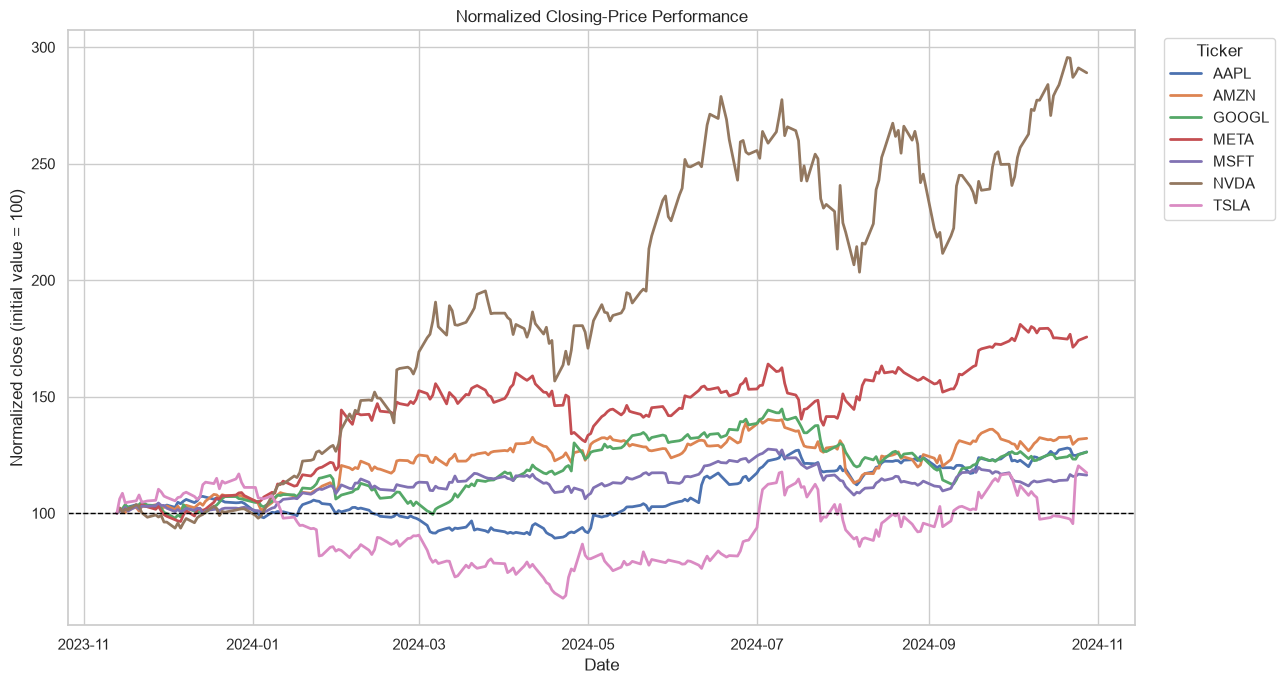

In [20]:
fig, ax = plt.subplots(figsize=(13, 7))

sns.lineplot(
    data=eda_prices,
    x="date",
    y="normalized_close",
    hue="ticker",
    linewidth=2,
    ax=ax,
)

ax.axhline(100, color="black", linestyle="--", linewidth=1)
ax.set(
    title="Normalized Closing-Price Performance",
    xlabel="Date",
    ylabel="Normalized close (initial value = 100)",
)

ax.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "normalized_price_performance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Return distributions

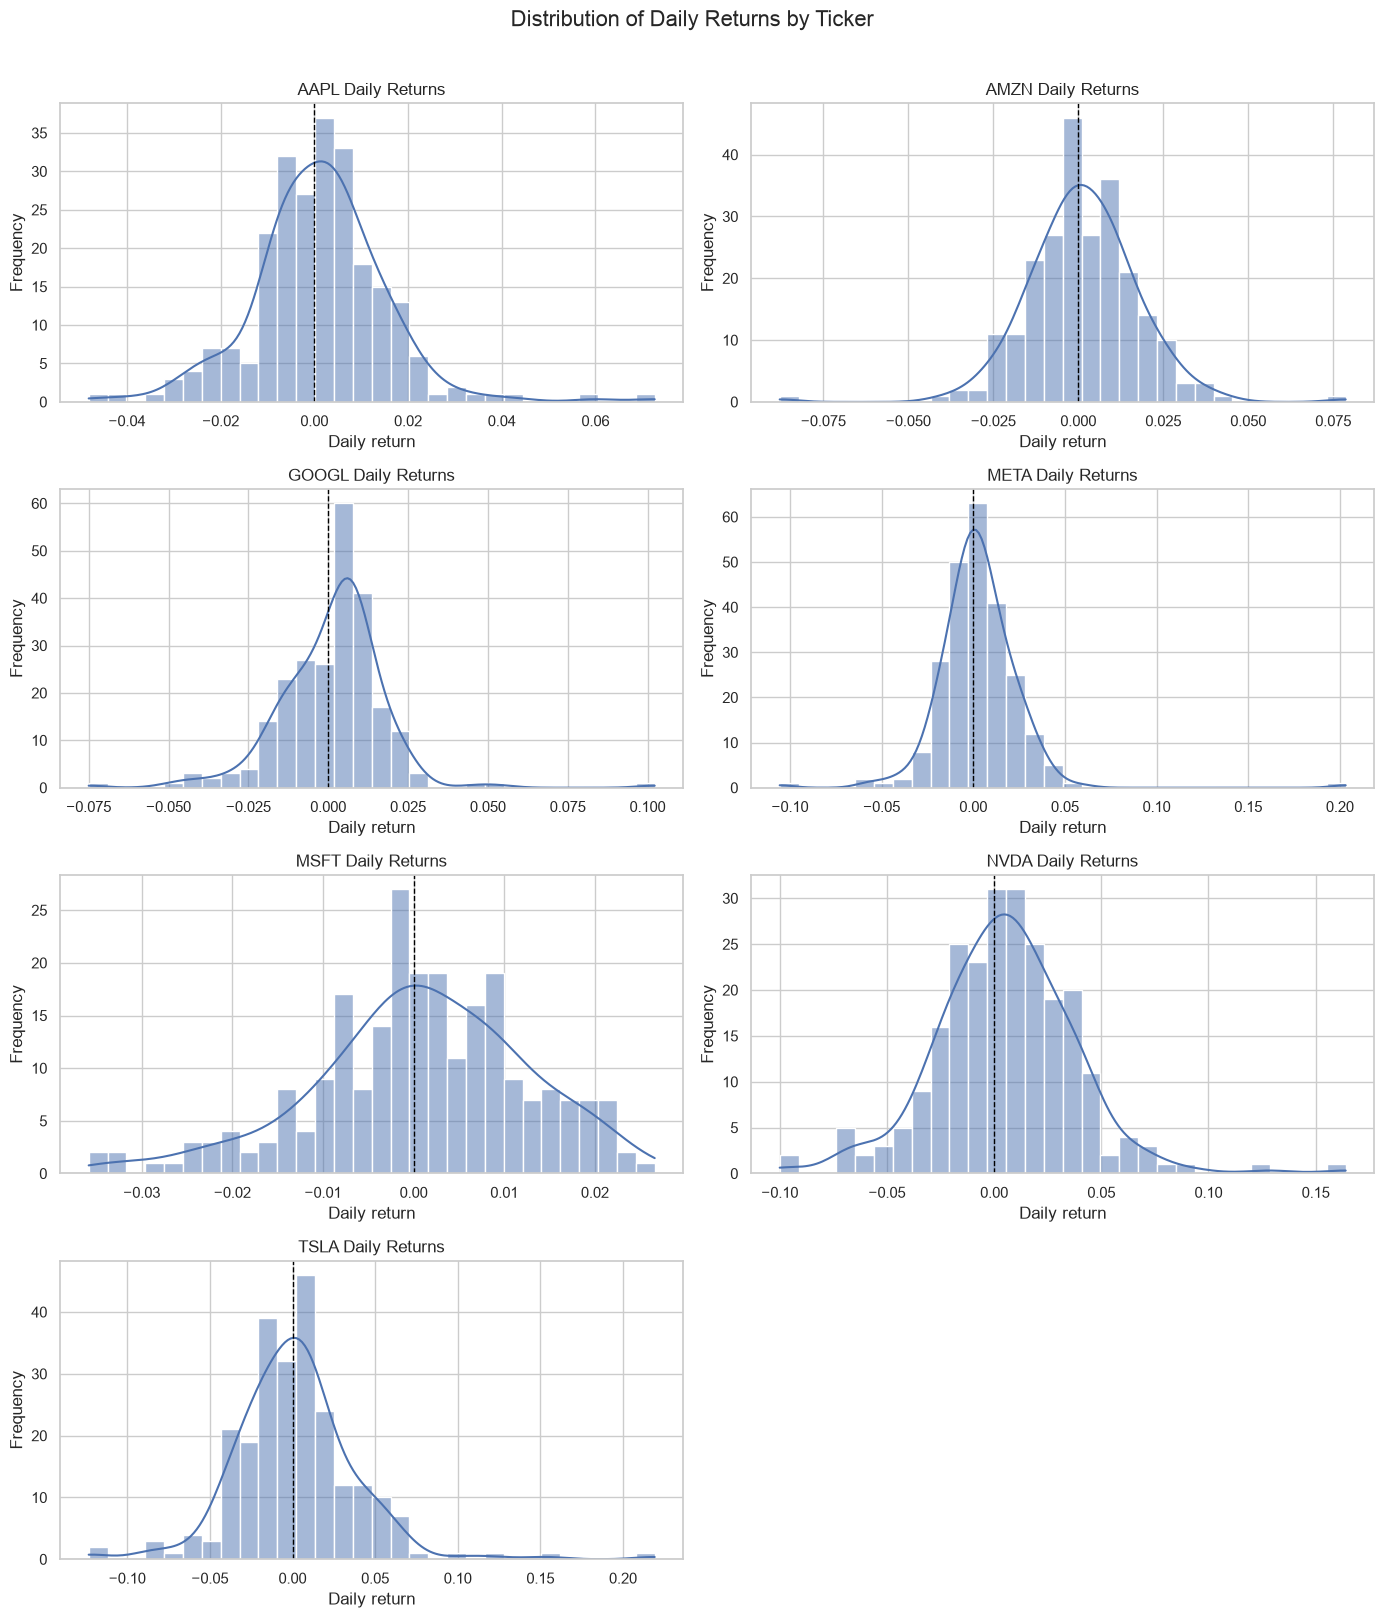

In [21]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, (ticker, group) in zip(
    axes,
    eda_prices.groupby("ticker"),
):
    sns.histplot(
        group["daily_return"].dropna(),
        bins=30,
        kde=True,
        ax=ax,
    )

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set(
        title=f"{ticker} Daily Returns",
        xlabel="Daily return",
        ylabel="Frequency",
    )

axes[-1].axis("off")
fig.suptitle("Distribution of Daily Returns by Ticker", fontsize=16, y=1.01)
fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "daily_return_distributions.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Closing-price correlation

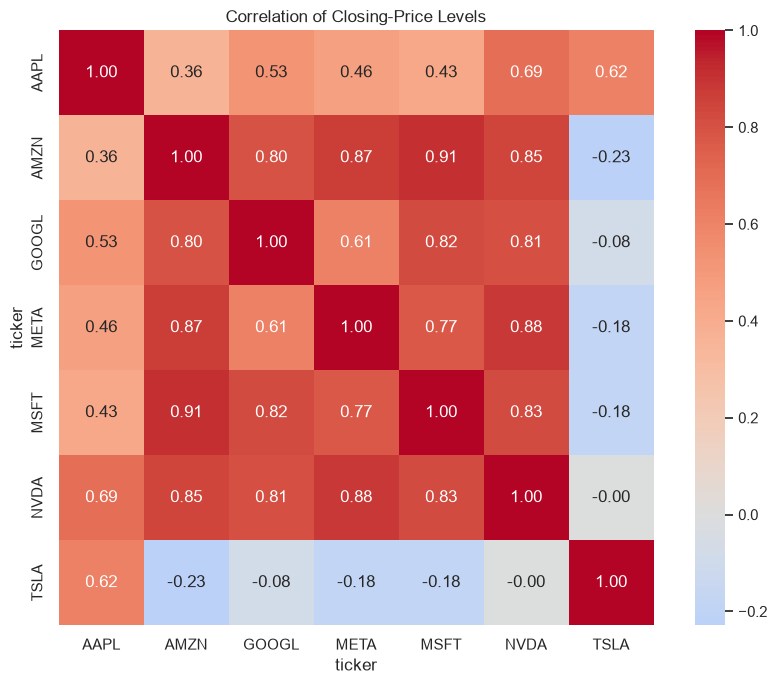

In [22]:
close_matrix = (
    eda_prices
    .pivot(index="date", columns="ticker", values="close")
)

close_correlation = close_matrix.corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    close_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax,
)

ax.set_title("Correlation of Closing-Price Levels")
fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "closing_price_correlation.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Daily-return correlation

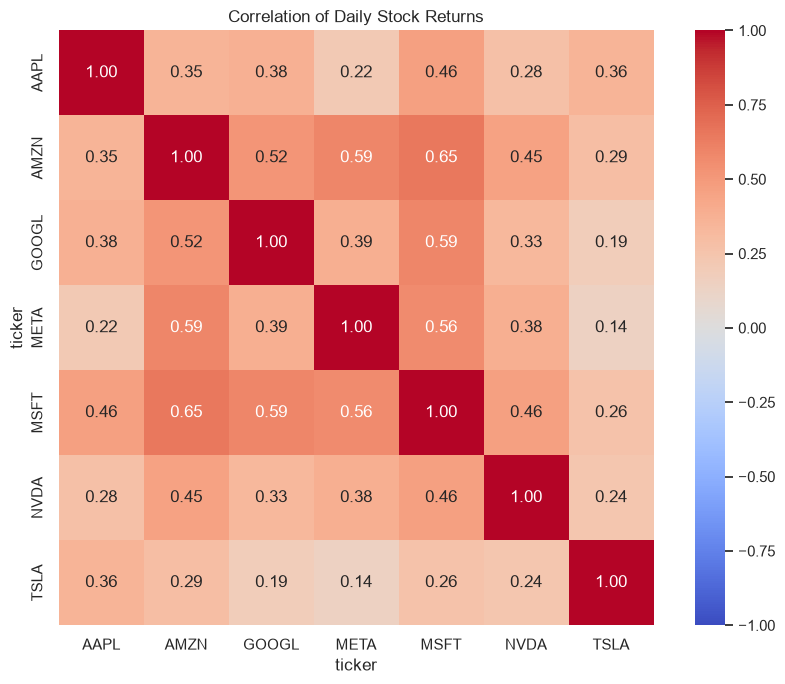

In [23]:
return_matrix = (
    eda_prices
    .pivot(index="date", columns="ticker", values="daily_return")
)

return_correlation = return_matrix.corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    return_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)

ax.set_title("Correlation of Daily Stock Returns")
fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "daily_return_correlation.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [24]:
display(
    ticker_statistics[
        [
            "daily_volatility",
            "annualized_volatility",
            "minimum_daily_return",
            "maximum_daily_return",
        ]
    ]
    .sort_values("daily_volatility", ascending=False)
    .style.format(
        {
            "daily_volatility": "{:.3%}",
            "annualized_volatility": "{:.2%}",
            "minimum_daily_return": "{:.2%}",
            "maximum_daily_return": "{:.2%}",
        }
    )
)

,daily_volatility,annualized_volatility,minimum_daily_return,maximum_daily_return
ticker,,,,
TSLA,3.705%,58.82%,-12.33%,21.92%
NVDA,3.300%,52.39%,-10.00%,16.40%
META,2.288%,36.31%,-10.56%,20.32%
GOOGL,1.657%,26.30%,-7.50%,10.22%
AMZN,1.645%,26.11%,-8.78%,7.87%
AAPL,1.428%,22.67%,-4.82%,7.26%
MSFT,1.177%,18.69%,-3.59%,2.66%


Tesla and NVIDIA were the most volatile securities, with daily return
volatilities of approximately 3.71% and 3.30%, respectively. Meta ranked third
at 2.29%. Tesla also displayed the widest observed return extremes, ranging
from -12.33% to 21.92%, indicating a substantial degree of company-specific
risk during the sample.

Microsoft was the least volatile stock, with daily volatility of approximately
1.18% and a considerably narrower range of observed returns. NVIDIA combined
high volatility with the strongest cumulative performance, appreciating
approximately 189% over the observation period. High volatility therefore did
not necessarily correspond to weak performance in this sample.

Extreme return days

In [26]:
extreme_returns = (
    eda_prices
    .dropna(subset=["daily_return"])
    .loc[
        :,
        ["date", "ticker", "close", "daily_return", "volume"],
    ]
    .assign(
        absolute_return=lambda df: df["daily_return"].abs()
    )
    .sort_values("absolute_return", ascending=False)
)

display(
    extreme_returns
    .head(20)
    .style.format(
        {
            "close": "${:,.2f}",
            "daily_return": "{:.2%}",
            "absolute_return": "{:.2%}",
            "volume": "{:,.0f}",
        }
    )
)

,date,ticker,close,daily_return,volume,absolute_return
1684,2024-10-24 00:00:00,TSLA,$260.48,21.92%,"204,491,900",21.92%
778,2024-02-02 00:00:00,META,$474.99,20.32%,"84,615,500",20.32%
1273,2024-02-22 00:00:00,NVDA,$78.54,16.40%,"865,100,000",16.40%
1560,2024-04-29 00:00:00,TSLA,$194.05,15.31%,"243,869,700",15.31%
1383,2024-07-31 00:00:00,NVDA,$117.02,12.81%,"473,174,200",12.81%
1619,2024-07-24 00:00:00,TSLA,$215.99,-12.33%,"167,942,900",12.33%
1495,2024-01-25 00:00:00,TSLA,$182.63,-12.13%,"198,076,800",12.13%
1557,2024-04-24 00:00:00,TSLA,$162.13,12.06%,"181,178,000",12.06%
835,2024-04-25 00:00:00,META,$441.38,-10.56%,"82,890,700",10.56%
595,2024-04-26 00:00:00,GOOGL,$171.95,10.22%,"64,665,300",10.22%


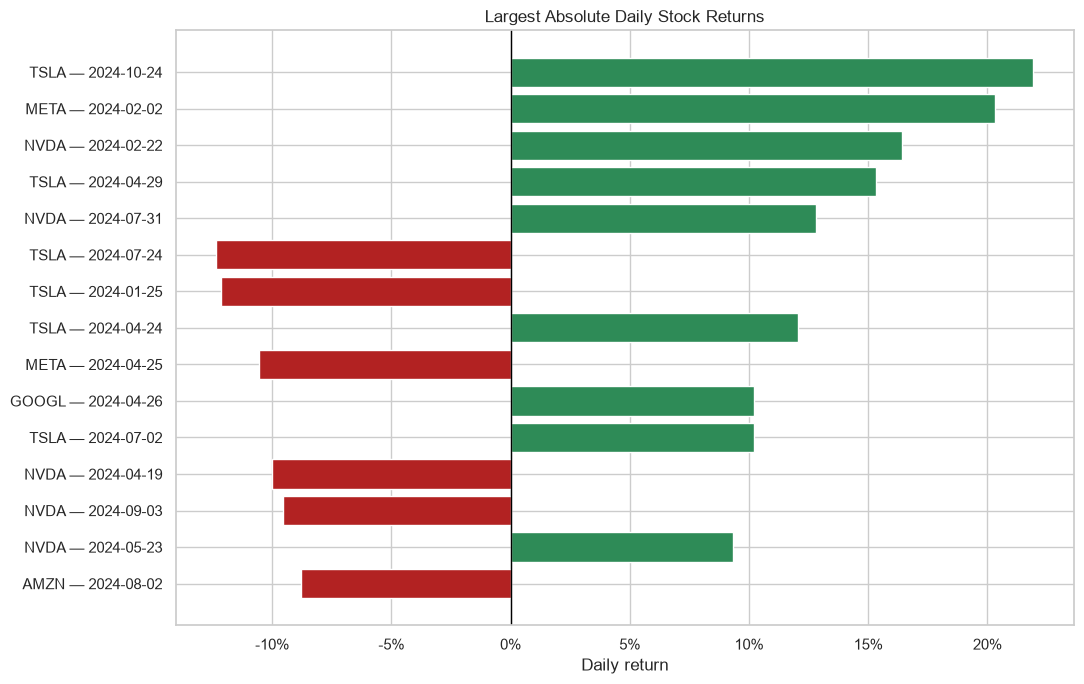

In [27]:
top_extreme_returns = extreme_returns.head(15).copy()

top_extreme_returns["label"] = (
    top_extreme_returns["ticker"]
    + " — "
    + top_extreme_returns["date"].dt.strftime("%Y-%m-%d")
)

fig, ax = plt.subplots(figsize=(11, 7))

colors = np.where(
    top_extreme_returns["daily_return"] >= 0,
    "seagreen",
    "firebrick",
)

ax.barh(
    top_extreme_returns["label"],
    top_extreme_returns["daily_return"],
    color=colors,
)

ax.axvline(0, color="black", linewidth=1)
ax.invert_yaxis()
ax.set(
    title="Largest Absolute Daily Stock Returns",
    xlabel="Daily return",
    ylabel="",
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "largest_daily_returns.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Extreme-return observations

The largest daily movements are concentrated among the most volatile stocks,
particularly Tesla, NVIDIA, and Meta. These observations are not automatically
removed because large movements are plausible and economically meaningful in
financial markets. Removing them would suppress precisely the behavior the
forecasting model must learn to handle.

Model evaluation will therefore include error analysis on high-volatility days
rather than treating extreme returns as data-quality errors.

News coverage

In [28]:
news_eda = news.copy()
news_eda["calendar_date"] = news_eda["datetime"].dt.normalize()

daily_news = (
    news_eda
    .groupby(["calendar_date", "ticker"])
    .agg(
        article_count=("headline", "size"),
        unique_headlines=("headline", "nunique"),
    )
    .reset_index()
)

news_summary = (
    news_eda
    .groupby("ticker")
    .agg(
        total_articles=("headline", "size"),
        unique_headlines=("headline", "nunique"),
        active_news_days=("calendar_date", "nunique"),
        first_article=("datetime", "min"),
        last_article=("datetime", "max"),
    )
)

news_summary["articles_per_active_day"] = (
    news_summary["total_articles"]
    / news_summary["active_news_days"]
)

display(
    news_summary.sort_values(
        "total_articles",
        ascending=False,
    )
)

,total_articles,unique_headlines,active_news_days,first_article,last_article,articles_per_active_day
ticker,,,,,,
AMZN,941,891,238,2023-11-13 12:38:25,2024-10-29 11:35:05,3.9538
AAPL,799,768,224,2023-11-13 17:35:52,2024-10-29 18:07:48,3.5670
TSLA,794,759,225,2023-11-13 09:12:41,2024-10-29 16:59:40,3.5289
NVDA,594,590,173,2023-11-14 05:35:10,2024-10-28 17:53:12,3.4335
MSFT,535,528,193,2023-11-13 14:53:47,2024-10-29 12:42:25,2.7720
META,391,381,179,2023-11-16 15:34:02,2024-10-29 19:06:19,2.1844
GOOGL,385,384,155,2023-11-14 12:07:58,2024-10-29 19:34:15,2.4839


News Volume By Ticker

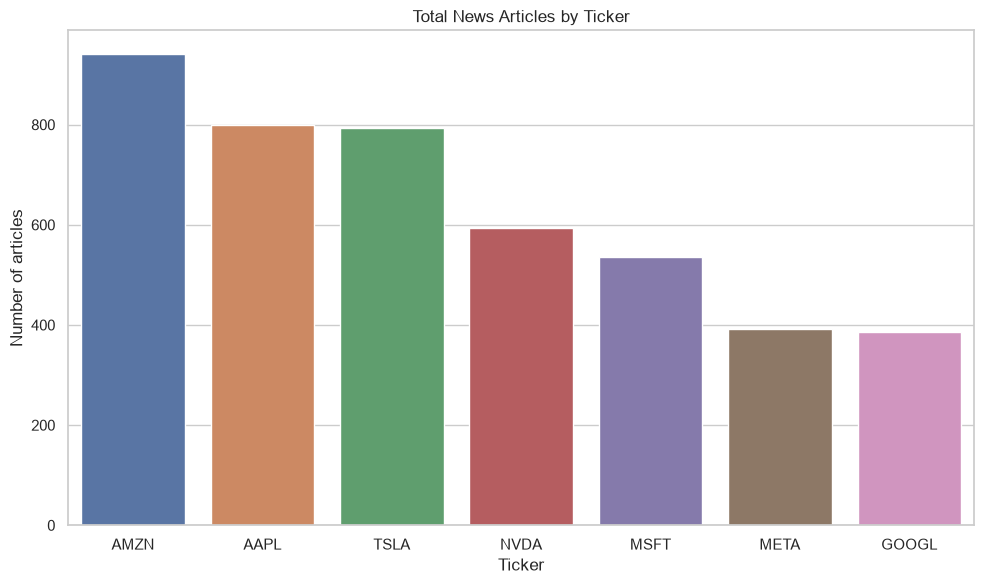

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = (
    news_summary
    .sort_values("total_articles", ascending=False)
    .reset_index()
)

sns.barplot(
    data=plot_data,
    x="ticker",
    y="total_articles",
    hue="ticker",
    legend=False,
    ax=ax,
)

ax.set(
    title="Total News Articles by Ticker",
    xlabel="Ticker",
    ylabel="Number of articles",
)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "news_articles_by_ticker.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

News Activity Over Time

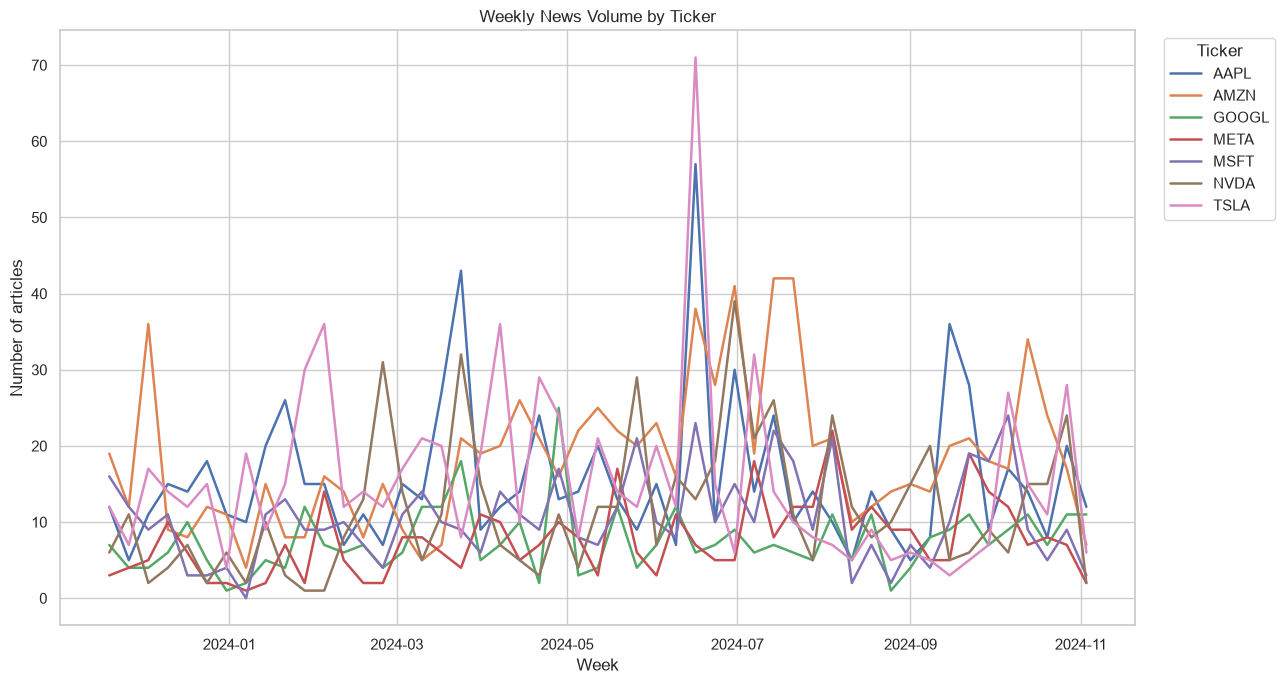

In [30]:
weekly_news = (
    news_eda
    .set_index("datetime")
    .groupby("ticker")
    .resample("W")["headline"]
    .size()
    .rename("article_count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 7))

sns.lineplot(
    data=weekly_news,
    x="datetime",
    y="article_count",
    hue="ticker",
    linewidth=1.8,
    ax=ax,
)

ax.set(
    title="Weekly News Volume by Ticker",
    xlabel="Week",
    ylabel="Number of articles",
)

ax.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "weekly_news_volume.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### News-coverage findings

News coverage is uneven across securities. Some tickers receive substantially
more articles and have news available on a larger number of dates than others.
Consequently, article count may partially reflect differences in media
attention rather than only the importance of individual events.

The modeling pipeline will preserve days without news and represent them
explicitly rather than dropping them. Daily article counts, unique headline
counts, and eventually aggregated sentiment will be used as features. All news
must be assigned to a trading-information window before it is merged with price
data to prevent temporal leakage.

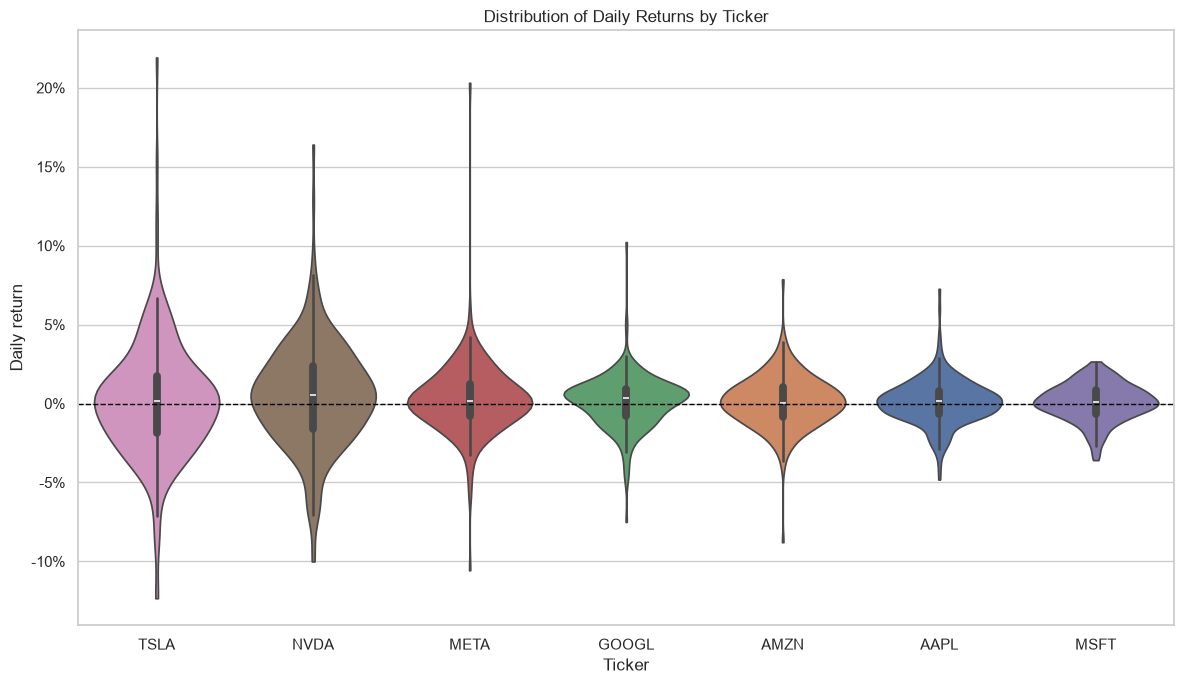

In [31]:
volatility_order = (
    eda_prices
    .groupby("ticker")["daily_return"]
    .std()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.violinplot(
    data=eda_prices.dropna(subset=["daily_return"]),
    x="ticker",
    y="daily_return",
    order=volatility_order,
    inner="box",
    cut=0,
    density_norm="width",
    hue="ticker",
    legend=False,
    ax=ax,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set(
    title="Distribution of Daily Returns by Ticker",
    xlabel="Ticker",
    ylabel="Daily return",
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "daily_return_violin_plot.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The violin plot reinforces the volatility ranking observed in the summary
statistics. Tesla and NVIDIA exhibit the widest return distributions and the
most pronounced tails, while Microsoft has the narrowest distribution. The
presence of heavy tails indicates that daily stock returns are not well
represented by a simple normal distribution and that large movements occur
more frequently than a Gaussian assumption would suggest.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [33]:
ticker_documents = (
    news
    .groupby("ticker")["headline"]
    .apply(" ".join)
)

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=2_000,
)

tfidf_matrix = vectorizer.fit_transform(ticker_documents)

terms = np.array(vectorizer.get_feature_names_out())

In [41]:
top_term_records = []

for row_number, ticker in enumerate(ticker_documents.index):
    scores = tfidf_matrix[row_number].toarray().ravel()
    top_indices = scores.argsort()[-12:][::-1]

    for rank, index in enumerate(top_indices, start=1):
        top_term_records.append(
            {
                "ticker": ticker,
                "term": terms[index],
                "tfidf_score": scores[index],
                "rank": rank,
            }
        )

top_terms = pd.DataFrame(top_term_records)

display(top_terms.head(50))
display(top_terms.tail(34))

,ticker,term,tfidf_score,rank
0,AAPL,apple,0.8150,1
1,AAPL,news,0.2368,2
2,AAPL,new,0.1235,3
3,AAPL,eu,0.1119,4
4,AAPL,company,0.1061,5
5,AAPL,day,0.1031,6
6,AAPL,highlights,0.1017,7
7,AAPL,news highlights,0.0988,8
8,AAPL,news day,0.0988,9
9,AAPL,et,0.0973,10


,ticker,term,tfidf_score,rank
50,MSFT,openai,0.3915,3
51,MSFT,says,0.1316,4
52,MSFT,altman,0.1154,5
53,MSFT,cloud,0.0967,6
54,MSFT,tech,0.0822,7
55,MSFT,sam altman,0.0791,8
56,MSFT,sam,0.0791,9
57,MSFT,new,0.0775,10
58,MSFT,billion,0.0775,11
59,MSFT,reports,0.0728,12


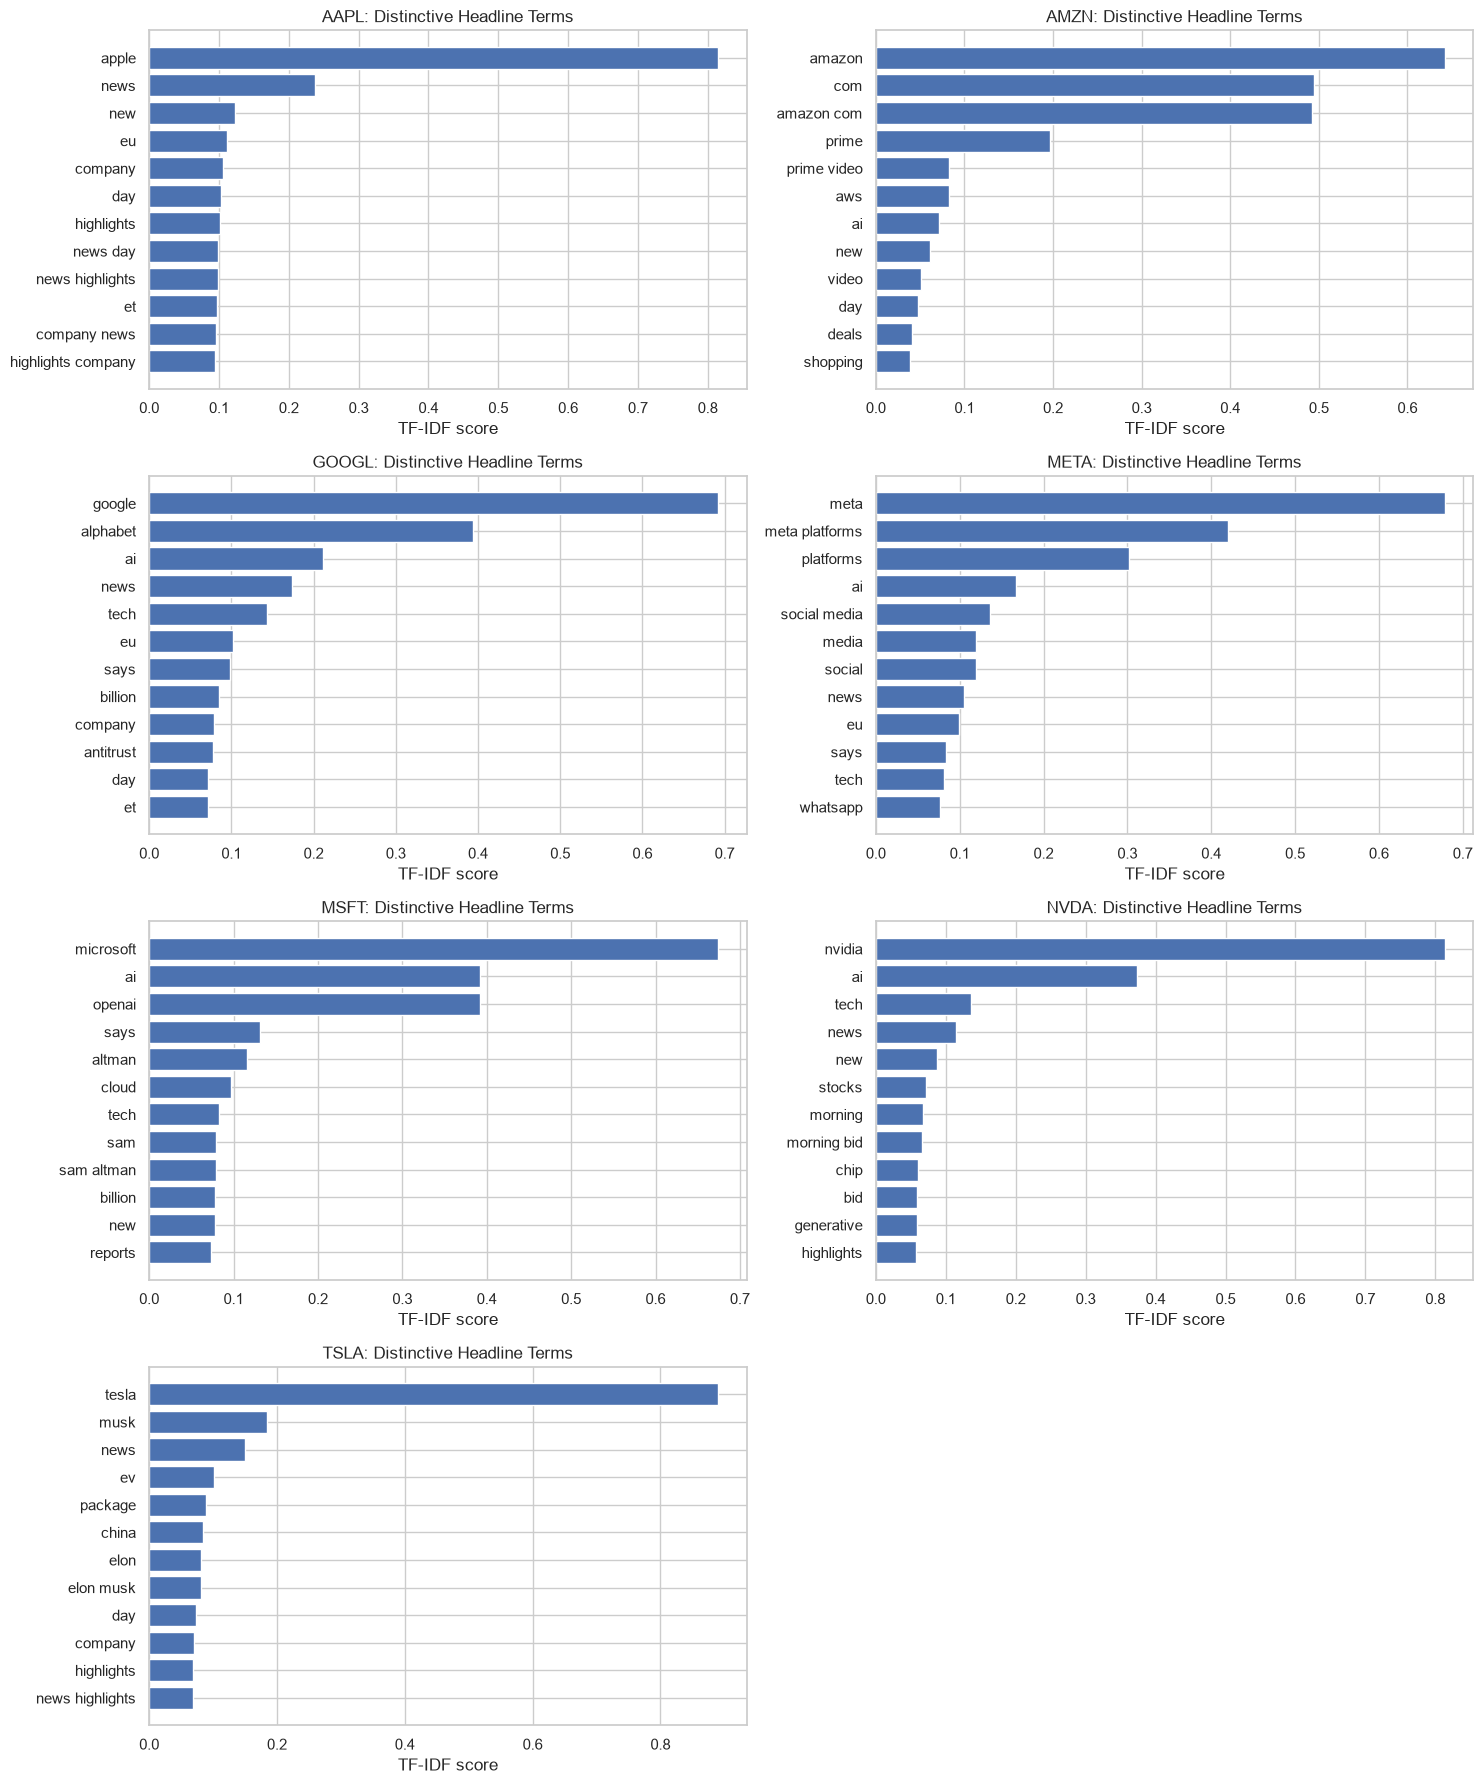

In [42]:
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for ax, ticker in zip(axes, ticker_documents.index):
    ticker_terms = (
        top_terms[top_terms["ticker"] == ticker]
        .sort_values("tfidf_score")
    )

    ax.barh(
        ticker_terms["term"],
        ticker_terms["tfidf_score"],
    )

    ax.set(
        title=f"{ticker}: Distinctive Headline Terms",
        xlabel="TF-IDF score",
        ylabel="",
    )

axes[-1].axis("off")
fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "distinctive_headline_terms.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()